# Europe's Energy Transition — Data Cleaning, Integration & EDA
**Data Visualizations 2026 Project**

## Research Question
> *Is Europe's energy transition actually working — and which countries are leading vs. lagging?*

## Datasets
| # | Dataset | Source | Coverage |
|---|---------|--------|----------|
| 1 | **OWID CO₂ & GHG Emissions** | Our World in Data (GitHub) | 38 European countries, 1990–2024 |
| 2 | **Energy Mix (Simplified Energy Balances)** | Eurostat `NRG_BAL_S` | 38 European countries, 1990–2024 |

## Notebook Structure
1. Imports & Setup  
2. Load Raw Datasets  
3. Inspect & Understand Structure  
4. Clean Dataset 1 — OWID  
5. Clean Dataset 2 — Eurostat Energy Mix  
6. Integrate — Merge into One Dataset  
7. Derive New Columns  
8. Validation & Quality Checks  
9. Exploratory Data Analysis (EDA)  
10. Key Findings & Design Implications  
11. Export Clean Dataset


## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# just so all columns show when we print dataframes
pd.set_option('display.max_columns', None)

## 2. Load Raw Datasets

In [3]:
owid_raw = pd.read_csv('/Users/kamiladoshchanova/Downloads/owid-co2-data.csv')
energy_raw = pd.read_csv('/Users/kamiladoshchanova/Downloads/energy_mix.csv')

print(owid_raw.shape)
owid_raw.head()

(50411, 79)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Inspect & Understand Structure

In [4]:
# OWID: full column list
owid_raw.dtypes

country                            str
year                             int64
iso_code                           str
population                     float64
gdp                            float64
                                ...   
temperature_change_from_n2o    float64
total_ghg                      float64
total_ghg_excluding_lucf       float64
trade_co2                      float64
trade_co2_share                float64
Length: 79, dtype: object

In [5]:
energy_raw.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,nrg_bal,Energy balance,siec,Standard international energy product classification (SIEC),unit,Unit of measure,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:NRG_BAL_S(1.0),Simplified energy balances,A,Annual,GAE,Gross available energy,C0000X0350-0370,Solid fossil fuels,KTOE,Thousand tonnes of oil equivalent,AL,Albania,1990,NaN,629.581,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:NRG_BAL_S(1.0),Simplified energy balances,A,Annual,GAE,Gross available energy,C0000X0350-0370,Solid fossil fuels,KTOE,Thousand tonnes of oil equivalent,AL,Albania,1991,NaN,375.039,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:NRG_BAL_S(1.0),Simplified energy balances,A,Annual,GAE,Gross available energy,C0000X0350-0370,Solid fossil fuels,KTOE,Thousand tonnes of oil equivalent,AL,Albania,1992,NaN,95.035,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:NRG_BAL_S(1.0),Simplified energy balances,A,Annual,GAE,Gross available energy,C0000X0350-0370,Solid fossil fuels,KTOE,Thousand tonnes of oil equivalent,AL,Albania,1993,NaN,48.430,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:NRG_BAL_S(1.0),Simplified energy balances,A,Annual,GAE,Gross available energy,C0000X0350-0370,Solid fossil fuels,KTOE,Thousand tonnes of oil equivalent,AL,Albania,1994,NaN,39.731,NaN,NaN,NaN,NaN,NaN


In [6]:
energy_raw['Standard international energy product classification (SIEC)'].unique()

<ArrowStringArray>
[                                    'Solid fossil fuels',
                                     'Manufactured gases',
                                            'Electricity',
                                            'Natural gas',
                                                   'Heat',
                                           'Nuclear heat',
 'Oil and petroleum products (excluding biofuel portion)',
                                 'Peat and peat products',
                                'Renewables and biofuels',
                                'Oil shale and oil sands',
                                                  'Total',
                                    'Non-renewable waste']
Length: 12, dtype: str

In [7]:
energy_raw['TIME_PERIOD'].min(), energy_raw['TIME_PERIOD'].max()

(np.int64(1990), np.int64(2024))

In [8]:
energy_raw['Geopolitical entity (reporting)'].nunique()

41

In [9]:
# the dataset mixes real countries with regional aggregates like "World", "Europe" etc.
# iso_code is NaN or starts with OWID for those — let's separate them

owid_real = owid_raw[owid_raw.iso_code.notna() & ~owid_raw.iso_code.str.startswith('OWID')]
owid_agg = owid_raw[owid_raw.iso_code.isna() | owid_raw.iso_code.str.startswith('OWID')]

print(owid_agg.country.unique())

<ArrowStringArray>
[                                  'Africa',
                             'Africa (GCP)',
                                     'Asia',
                               'Asia (GCP)',
             'Asia (excl. China and India)',
                    'Central America (GCP)',
                                   'Europe',
                             'Europe (GCP)',
                     'Europe (excl. EU-27)',
                     'Europe (excl. EU-28)',
                      'European Union (27)',
                      'European Union (28)',
                    'High-income countries',
                   'International aviation',
                   'International shipping',
                                   'Kosovo',
                        'Kuwaiti Oil Fires',
                  'Kuwaiti Oil Fires (GCP)',
 'Least developed countries (Jones et al.)',
                     'Low-income countries',
            'Lower-middle-income countries',
                        'Middle East

## 4. Clean Dataset 1 — OWID

In [10]:
# we only want european countries, owid has the whole world
# also filtering to 1990 onwards to match the energy mix data

countries = [
    'Albania', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria',
    'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France',
    'Georgia', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy',
    'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Montenegro',
    'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania',
    'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Ukraine', 'United Kingdom'
]

cols = ['country', 'year', 'iso_code', 'population', 'gdp',
        'co2', 'co2_per_capita', 'total_ghg', 'co2_per_unit_energy']

owid_clean = owid_raw[owid_raw.country.isin(countries) & owid_raw.year.between(1990, 2024)][cols].copy()
owid_clean.shape

(1330, 9)

In [11]:
owid_clean.isnull().sum()

country                 0
year                    0
iso_code                0
population              0
gdp                    76
co2                     0
co2_per_capita          0
total_ghg               0
co2_per_unit_energy    45
dtype: int64

In [12]:
owid_clean.duplicated(subset=['country', 'year']).sum()

np.int64(0)

## 5. Clean Dataset 2 — Eurostat Energy Mix

In [13]:
# eurostat exports with a ton of useless metadata columns, dropping them
energy = energy_raw.drop(columns=['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 
    'Time frequency', 'nrg_bal', 'Energy balance', 'Time', 'Observation value', 'OBS_FLAG',
    'Observation status (Flag) V2 structure', 'CONF_STATUS',
    'Confidentiality status (flag)', 'siec', 'Unit of measure'])

# rename to something readable
energy = energy.rename(columns={
    'Standard international energy product classification (SIEC)': 'siec',
    'Geopolitical entity (reporting)': 'country',
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'value'
})

energy.head()

,siec,unit,geo,country,year,value
0,Solid fossil fuels,KTOE,AL,Albania,1990,629.581
1,Solid fossil fuels,KTOE,AL,Albania,1991,375.039
2,Solid fossil fuels,KTOE,AL,Albania,1992,95.035
3,Solid fossil fuels,KTOE,AL,Albania,1993,48.430
4,Solid fossil fuels,KTOE,AL,Albania,1994,39.731


In [14]:
# filter to the same countries and years as owid
energy = energy[energy.country.isin(countries) & energy.year.between(1990, 2024)].copy()
energy.shape

(14868, 6)

In [15]:
energy.isnull().sum()

siec       0
unit       0
geo        0
country    0
year       0
value      0
dtype: int64

In [16]:
# currently in long format — need to pivot so each energy type becomes its own column
energy_wide = energy.pivot_table(index=['country', 'year'], columns='siec', values='value').reset_index()
energy_wide.columns.name = None
energy_wide.head()

,country,year,Electricity,Heat,Manufactured gases,Natural gas,Non-renewable waste,Nuclear heat,Oil and petroleum products (excluding biofuel portion),Oil shale and oil sands,Peat and peat products,Renewables and biofuels,Solid fossil fuels,Total
0,Albania,1990,17.713,0.0,0.0,203.203,0.0,0.0,1214.585,0.0,0.0,607.906,629.581,2672.987
1,Albania,1991,-100.860,0.0,0.0,118.229,0.0,0.0,812.972,0.0,0.0,665.515,375.039,1870.895
2,Albania,1992,-43.852,0.0,0.0,85.641,0.0,0.0,580.982,0.0,0.0,640.408,95.035,1358.214
3,Albania,1993,-12.296,0.0,0.0,68.444,0.0,0.0,595.092,0.0,0.0,631.446,48.430,1331.116
4,Albania,1994,-15.907,0.0,0.0,43.573,0.0,0.0,694.045,0.0,0.0,654.978,39.731,1416.420


In [17]:
energy_wide.isnull().sum()

country                                                   0
year                                                      0
Electricity                                               0
Heat                                                      0
Manufactured gases                                        0
Natural gas                                               0
Non-renewable waste                                       0
Nuclear heat                                              0
Oil and petroleum products (excluding biofuel portion)    0
Oil shale and oil sands                                   0
Peat and peat products                                    0
Renewables and biofuels                                   0
Solid fossil fuels                                        0
Total                                                     0
dtype: int64

In [18]:
# NaN means that country doesn't use that energy type — fill with 0
ecols = [c for c in energy_wide.columns if c not in ['country', 'year']]
energy_wide[ecols] = energy_wide[ecols].fillna(0)

## 6. Integrate — Merge into One Dataset

In [19]:
# inner join — only keep rows that exist in both datasets
merged = pd.merge(owid_clean, energy_wide, on=['country', 'year'], how='inner')
merged.shape

(1239, 21)

In [20]:
merged.head()

,country,year,iso_code,population,gdp,co2,co2_per_capita,total_ghg,co2_per_unit_energy,Electricity,Heat,Manufactured gases,Natural gas,Non-renewable waste,Nuclear heat,Oil and petroleum products (excluding biofuel portion),Oil shale and oil sands,Peat and peat products,Renewables and biofuels,Solid fossil fuels,Total
0,Albania,1990,ALB,3277965.0,1.294785e+10,5.521,1.684,12.001,0.198,17.713,0.0,0.0,203.203,0.0,0.0,1214.585,0.0,0.0,607.906,629.581,2672.987
1,Albania,1991,ALB,3282608.0,9.375857e+09,4.290,1.307,10.520,0.204,-100.860,0.0,0.0,118.229,0.0,0.0,812.972,0.0,0.0,665.515,375.039,1870.895
2,Albania,1992,ALB,3282506.0,8.745674e+09,2.517,0.767,7.667,0.138,-43.852,0.0,0.0,85.641,0.0,0.0,580.982,0.0,0.0,640.408,95.035,1358.214
3,Albania,1993,ALB,3277831.0,9.636342e+09,2.338,0.713,7.190,0.156,-12.296,0.0,0.0,68.444,0.0,0.0,595.092,0.0,0.0,631.446,48.430,1331.116
4,Albania,1994,ALB,3269417.0,1.059611e+10,1.924,0.588,7.232,0.148,-15.907,0.0,0.0,43.573,0.0,0.0,694.045,0.0,0.0,654.978,39.731,1416.420


## 7. Derive New Columns

In [21]:
# fossil total excludes non-renewable waste
fossil_cols = [
    'Solid fossil fuels',
    'Oil and petroleum products (excluding biofuel portion)',
    'Natural gas',
    'Oil shale and oil sands',
    'Peat and peat products'
]
merged['fossil_share_total'] = merged[fossil_cols].sum(axis=1)
merged['renewable_share_pct'] = merged['Renewables and biofuels'] / merged['Total'] * 100
merged['fossil_share_pct'] = merged['fossil_share_total'] / merged['Total'] * 100
merged['co2_per_unit_energy'] = merged['co2'] / merged['Total']

merged[['country', 'year', 'renewable_share_pct', 'fossil_share_pct', 'co2_per_unit_energy']].head()

,country,year,renewable_share_pct,fossil_share_pct,co2_per_unit_energy
0,Albania,1990,22.742572,76.594798,0.002065
1,Albania,1991,35.572012,69.818990,0.002293
2,Albania,1992,47.150744,56.077908,0.001853
3,Albania,1993,47.437338,53.486398,0.001756
4,Albania,1994,46.241793,54.881250,0.001358


In [22]:
final_cols = [
    'country', 'year', 'iso_code', 'population', 'gdp',
    'co2', 'co2_per_capita', 'total_ghg',
    'Electricity', 'Heat', 'Manufactured gases', 'Natural gas',
    'Non-renewable waste', 'Nuclear heat',
    'Oil and petroleum products (excluding biofuel portion)',
    'Oil shale and oil sands', 'Peat and peat products',
    'Renewables and biofuels', 'Solid fossil fuels', 'Total',
    'renewable_share_pct', 'fossil_share_total', 'fossil_share_pct',
    'co2_per_unit_energy'
]
merged = merged[final_cols]
merged.shape

(1239, 24)

## 8. Validation & Quality Checks

In [23]:
merged.shape

(1239, 24)

In [24]:
# gdp has some missing values — expected, owid doesn't have it for every country/year
merged.isnull().sum()

country                                                    0
year                                                       0
iso_code                                                   0
population                                                 0
gdp                                                       72
co2                                                        0
co2_per_capita                                             0
total_ghg                                                  0
Electricity                                                0
Heat                                                       0
Manufactured gases                                         0
Natural gas                                                0
Non-renewable waste                                        0
Nuclear heat                                               0
Oil and petroleum products (excluding biofuel portion)     0
Oil shale and oil sands                                    0
Peat and peat products  

In [25]:
merged.duplicated(subset=['country', 'year']).sum()

np.int64(0)

In [26]:
merged.country.unique()

<ArrowStringArray>
[               'Albania',                'Austria',                'Belgium',
 'Bosnia and Herzegovina',               'Bulgaria',                'Croatia',
                 'Cyprus',                'Czechia',                'Denmark',
                'Estonia',                'Finland',                 'France',
                'Georgia',                'Germany',                 'Greece',
                'Hungary',                'Iceland',                'Ireland',
                  'Italy',                 'Latvia',              'Lithuania',
             'Luxembourg',                  'Malta',                'Moldova',
             'Montenegro',            'Netherlands',        'North Macedonia',
                 'Norway',                 'Poland',               'Portugal',
                'Romania',                 'Serbia',               'Slovakia',
               'Slovenia',                  'Spain',                 'Sweden',
                'Ukraine',       

In [27]:
merged.groupby('country')['year'].agg(['min', 'max', 'count'])

,min,max,count
country,,,
Albania,1990,2024,35
Austria,1990,2024,35
Belgium,1990,2024,35
Bosnia and Herzegovina,2014,2024,11
Bulgaria,1990,2024,35
Croatia,1990,2024,35
Cyprus,1990,2024,35
Czechia,1990,2024,35
Denmark,1990,2024,35


In [28]:
merged[['renewable_share_pct', 'fossil_share_pct', 'co2_per_unit_energy']].describe()

,renewable_share_pct,fossil_share_pct,co2_per_unit_energy
count,1239.000000,1239.000000,1239.000000
mean,15.814823,75.148369,0.002223
std,15.868922,17.433277,0.000645
min,0.000000,12.055039,0.000507
25%,4.606762,65.666997,0.001809
50%,11.246094,78.372787,0.002278
75%,21.640090,88.461798,0.002665
max,87.944961,103.791205,0.004501


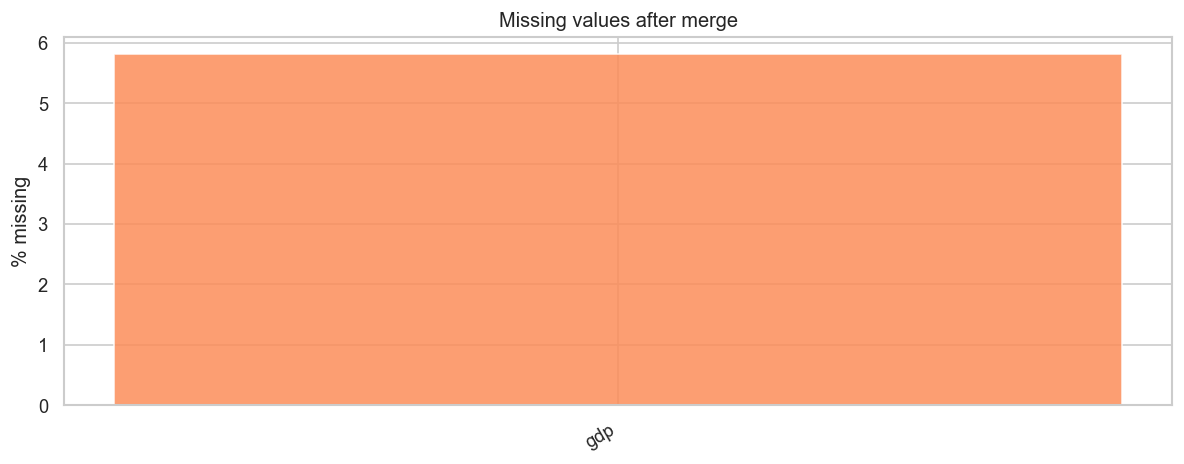

In [29]:
null_by_col = (merged.isnull().mean() * 100)
null_by_col = null_by_col[null_by_col > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(null_by_col.index, null_by_col.values, color='#fc8d59', alpha=0.85)
ax.set_ylabel('% missing')
ax.set_title('Missing values after merge')
ax.set_xticklabels(null_by_col.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()

GDP has missing values 5.8%. Every other column is complete

## 9. Exploratory Data Analysis (EDA)

### 9.1 Renewable Energy Share — Top & Bottom Countries (2024)

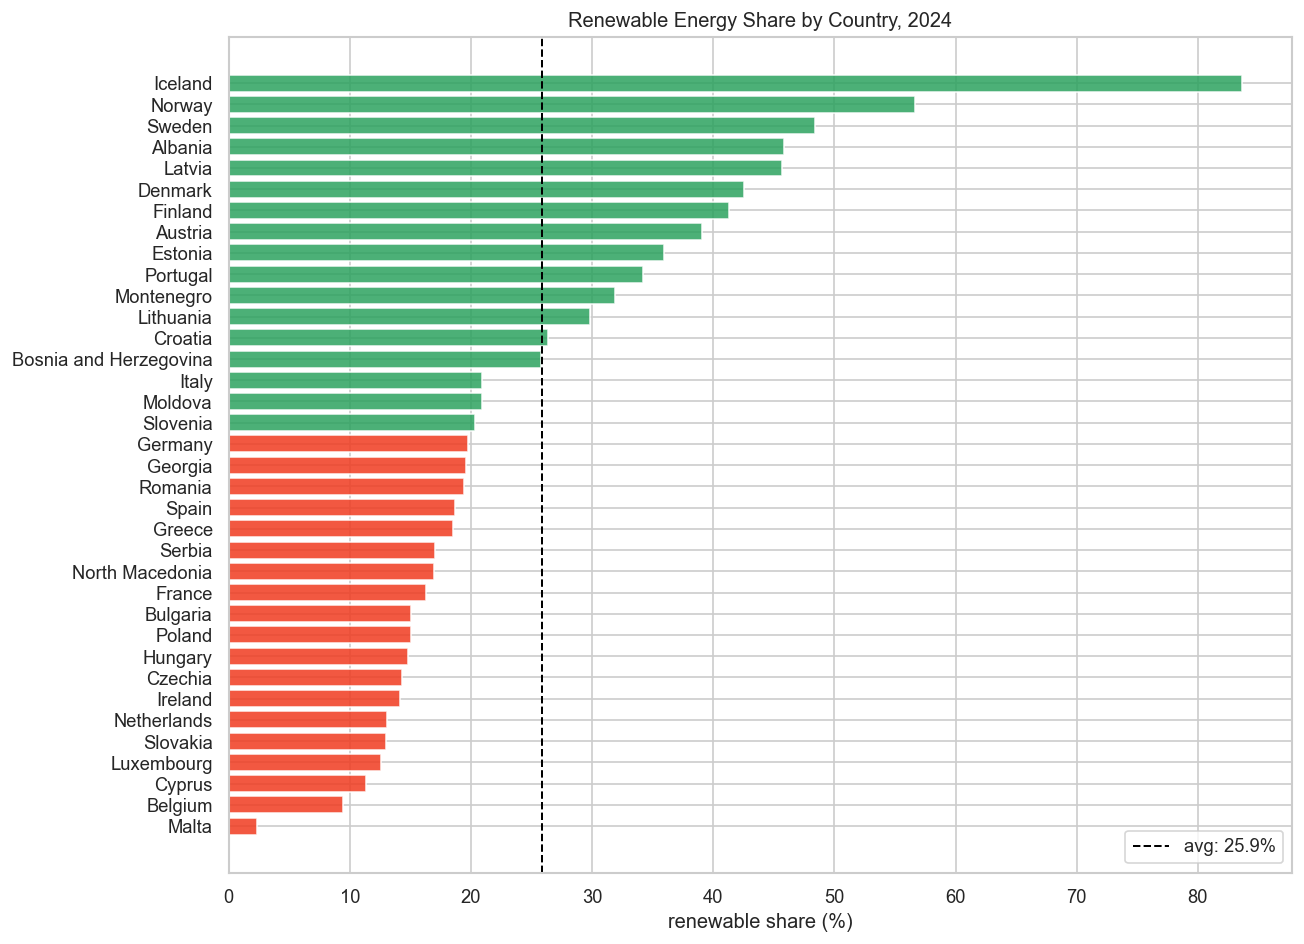

In [30]:
latest = merged[merged.year == 2024].sort_values('renewable_share_pct')

fig, ax = plt.subplots(figsize=(11, 8))
colors = ['#2ca25f' if v > 20 else '#f03b20' for v in latest.renewable_share_pct]
ax.barh(latest.country, latest.renewable_share_pct, color=colors, alpha=0.85)
ax.axvline(latest.renewable_share_pct.mean(), color='black', lw=1.2,
           linestyle='--', label=f'avg: {latest.renewable_share_pct.mean():.1f}%')
ax.set_xlabel('renewable share (%)')
ax.set_title('Renewable Energy Share by Country, 2024')
ax.legend()
plt.tight_layout()
plt.show()

### 9.2 Renewable Share Over Time — Selected Countries

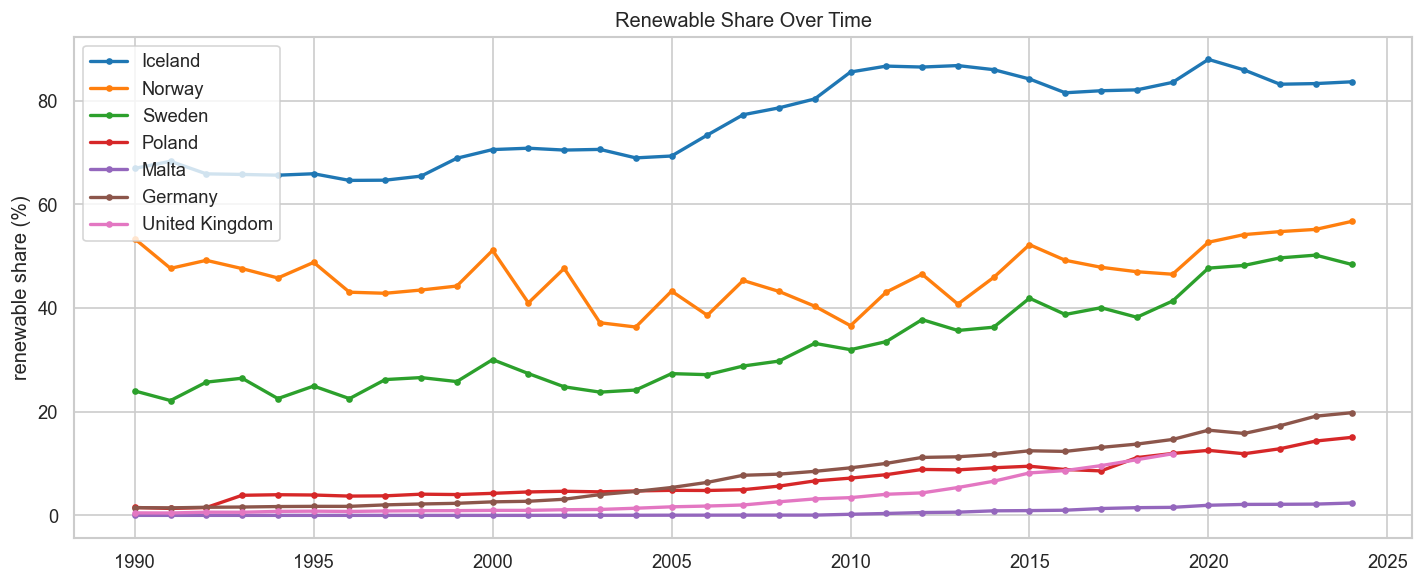

In [31]:
highlight = ['Iceland', 'Norway', 'Sweden', 'Poland', 'Malta', 'Germany', 'United Kingdom']
palette = sns.color_palette('tab10', len(highlight))

fig, ax = plt.subplots(figsize=(12, 5))
for i, c in enumerate(highlight):
    d = merged[merged.country == c].sort_values('year')
    ax.plot(d.year, d.renewable_share_pct, marker='o', markersize=3, label=c, color=palette[i], lw=2)

ax.set_ylabel('renewable share (%)')
ax.set_title('Renewable Share Over Time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 9.3 Energy Mix Breakdown — EU Average 2024

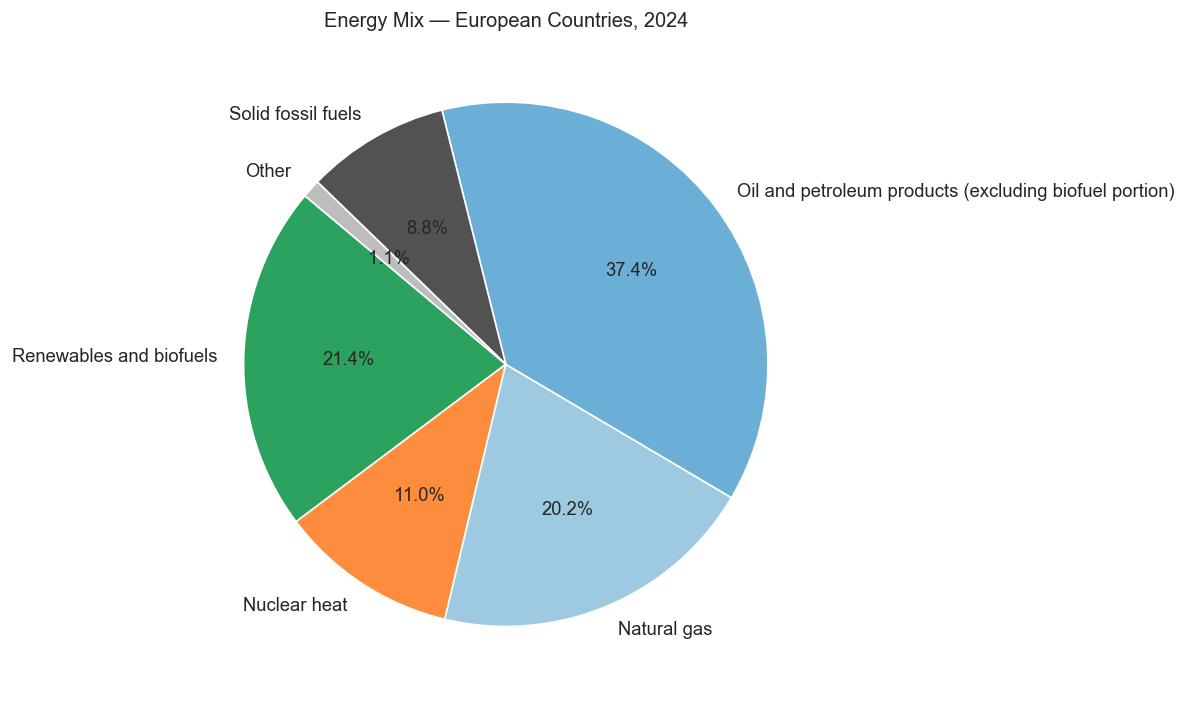

In [32]:
avg_2024 = merged[merged.year == 2024].copy()
avg_2024['Other'] = (avg_2024['Electricity'] + avg_2024['Heat'] +
                     avg_2024['Manufactured gases'] + avg_2024['Non-renewable waste'] +
                     avg_2024['Oil shale and oil sands'] + avg_2024['Peat and peat products'])

energy_cols_plot = ['Renewables and biofuels', 'Nuclear heat', 'Natural gas',
                    'Oil and petroleum products (excluding biofuel portion)',
                    'Solid fossil fuels', 'Other']
totals = avg_2024[energy_cols_plot].sum()

fig, ax = plt.subplots(figsize=(9, 6))
colors_pie = ['#2ca25f', '#fd8d3c', '#9ecae1', '#6baed6', '#525252', '#bdbdbd']
ax.pie(totals, labels=totals.index, autopct='%1.1f%%', colors=colors_pie, startangle=140)
ax.set_title('Energy Mix — European Countries, 2024')
plt.tight_layout()
plt.show()

### 9.4 CO₂ vs Renewable Share — Is the Transition Working?

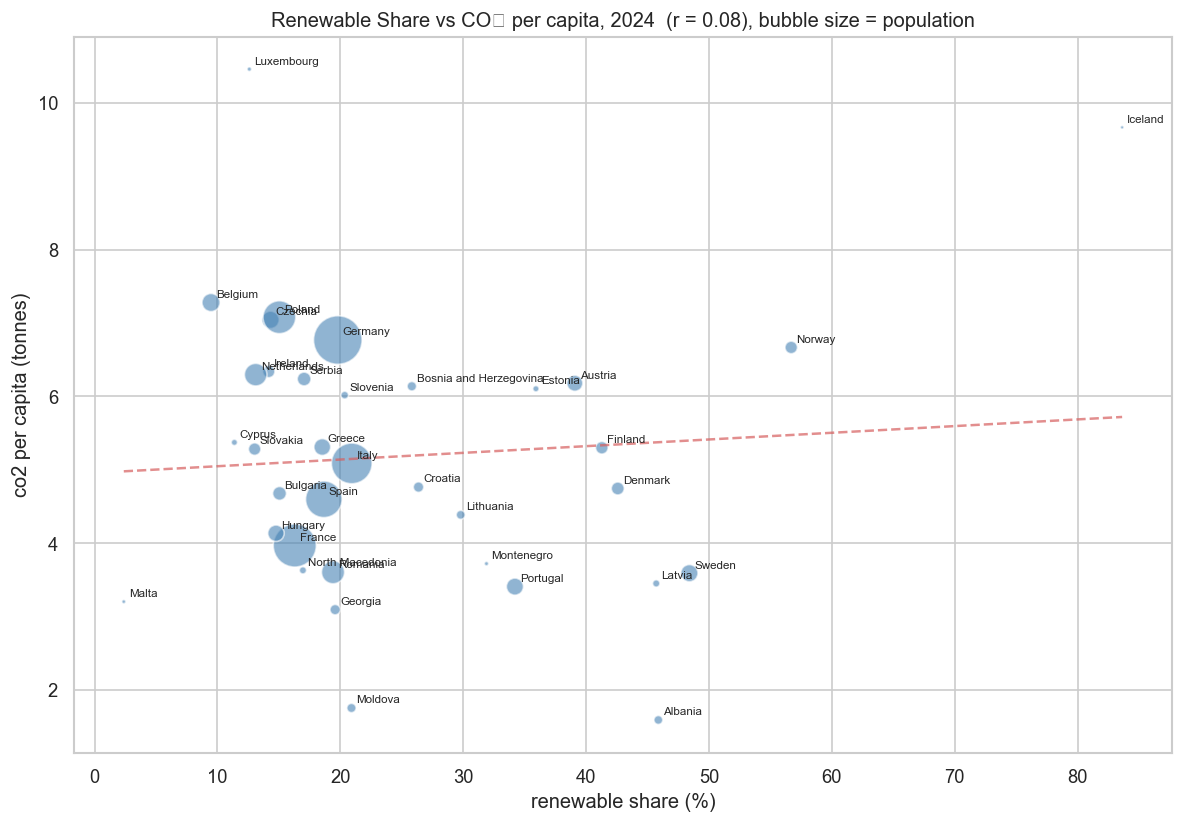

In [33]:
d2024 = merged[merged.year == 2024].dropna(subset=['co2_per_capita', 'renewable_share_pct'])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(d2024.renewable_share_pct, d2024.co2_per_capita,
           s=d2024.population / 1e5, alpha=0.6, color='steelblue', edgecolors='white')

for _, row in d2024.iterrows():
    ax.annotate(row.country, (row.renewable_share_pct, row.co2_per_capita),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

z = np.polyfit(d2024.renewable_share_pct, d2024.co2_per_capita, 1)
xr = np.linspace(d2024.renewable_share_pct.min(), d2024.renewable_share_pct.max(), 100)
ax.plot(xr, np.poly1d(z)(xr), 'r--', lw=1.5, alpha=0.7)

corr = d2024[['renewable_share_pct', 'co2_per_capita']].corr().iloc[0, 1]
ax.set_title(f'Renewable Share vs CO₂ per capita, 2024  (r = {corr:.2f}), bubble size = population')
ax.set_xlabel('renewable share (%)')
ax.set_ylabel('co2 per capita (tonnes)')
plt.tight_layout()
plt.show()

### 9.5 Fossil vs Renewable Share Heatmap — All Countries × Years

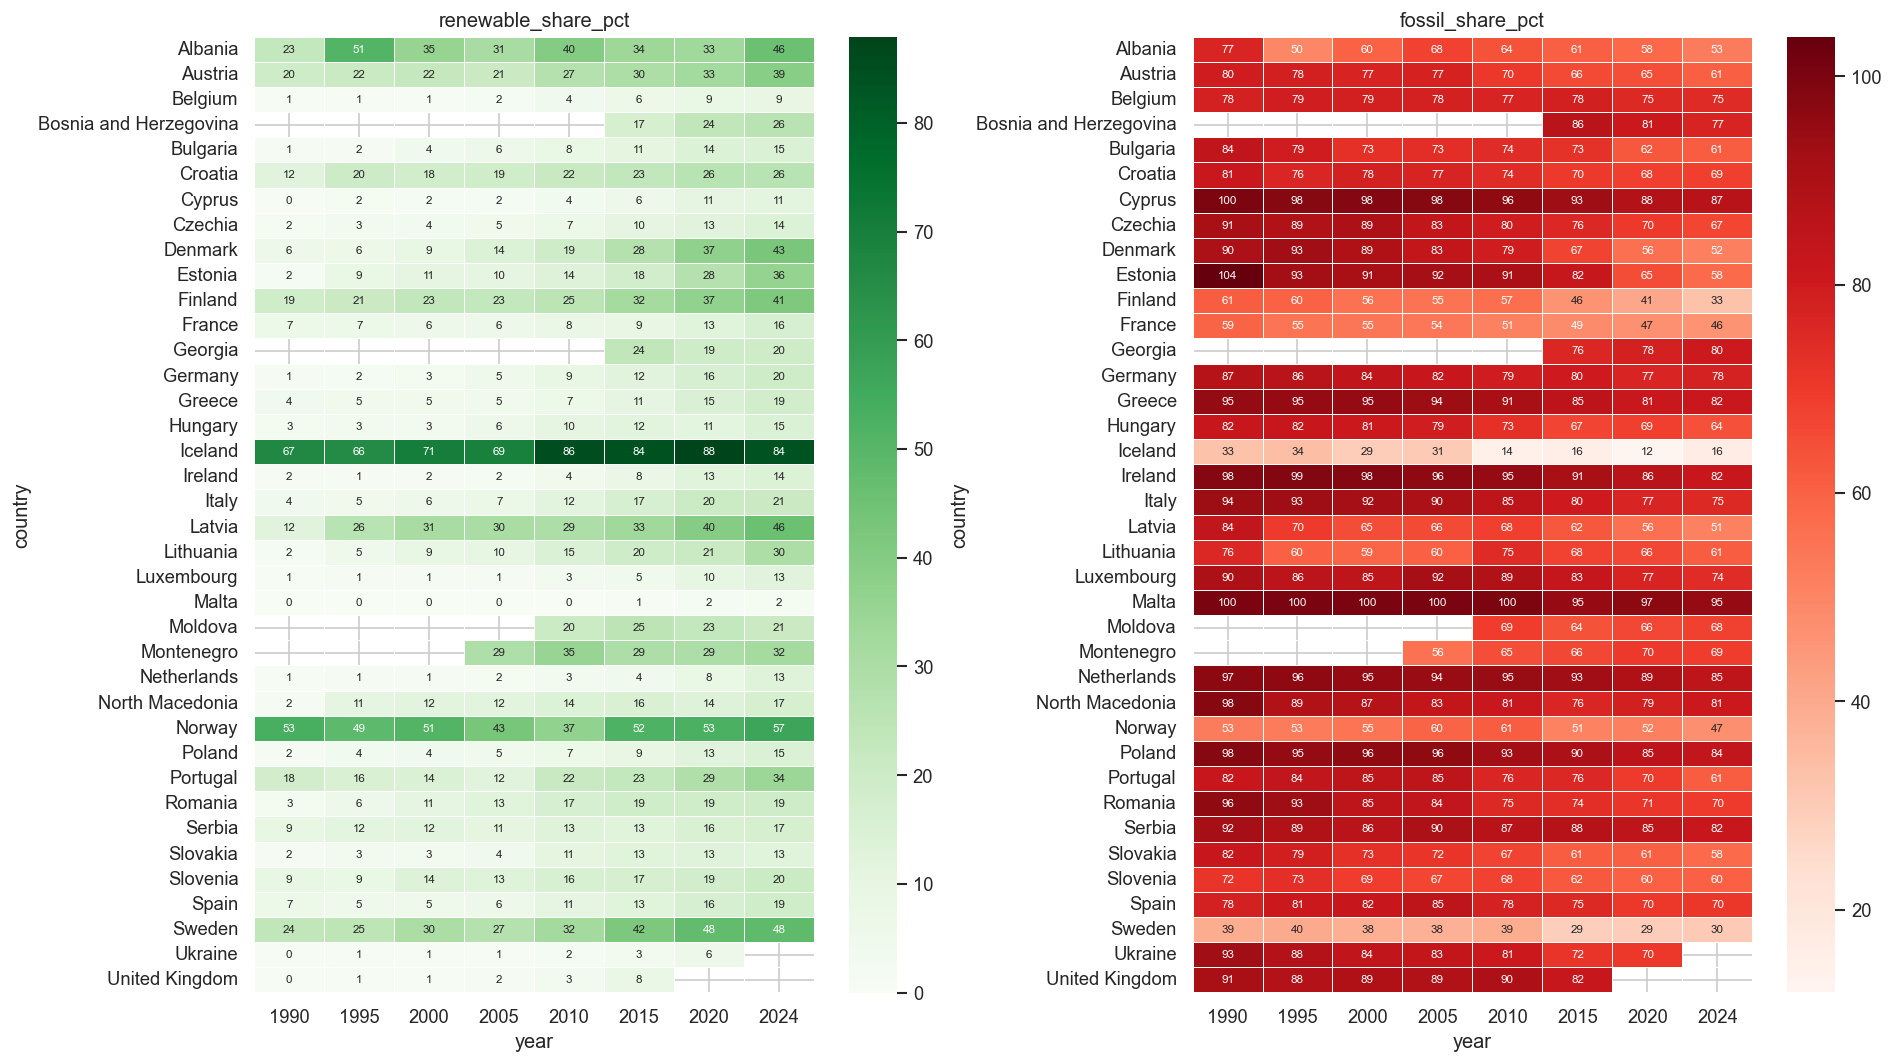

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

for ax, col, cmap in zip(axes, ['renewable_share_pct', 'fossil_share_pct'], ['Greens', 'Reds']):
    pivot = merged.pivot_table(index='country', columns='year', values=col)
    years = [y for y in pivot.columns if y % 5 == 0 or y == 2024]
    sns.heatmap(pivot[years], annot=True, fmt='.0f', cmap=cmap,
                linewidths=0.3, ax=ax, annot_kws={'size': 7})
    ax.set_title(col)

plt.tight_layout()
plt.show()

### 9.6 CO₂ Intensity of Energy — Cleaning Up Over Time?

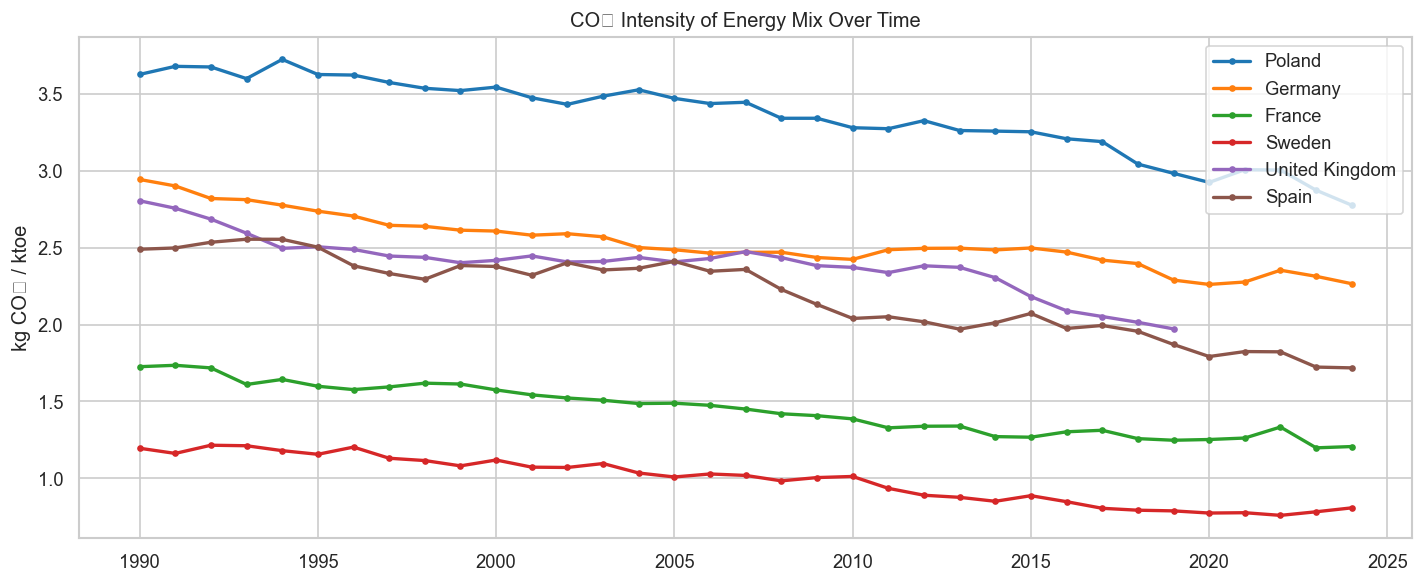

In [35]:
highlight = ['Poland', 'Germany', 'France', 'Sweden', 'United Kingdom', 'Spain']
palette = sns.color_palette('tab10', len(highlight))

fig, ax = plt.subplots(figsize=(12, 5))
for i, c in enumerate(highlight):
    d = merged[merged.country == c].sort_values('year')
    ax.plot(d.year, d.co2_per_unit_energy * 1000, label=c, color=palette[i], lw=2, marker='o', markersize=3)

ax.set_ylabel('kg CO₂ / ktoe')
ax.set_title('CO₂ Intensity of Energy Mix Over Time')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Key Findings & Design Implications

In [36]:
# top renewable leaders and fossil laggards in 2024
latest = merged[merged.year == 2024]

print('top 5 renewable:')
print(latest.nlargest(5, 'renewable_share_pct')[['country', 'renewable_share_pct']].to_string(index=False))

print('\ntop 5 fossil dependent:')
print(latest.nlargest(5, 'fossil_share_pct')[['country', 'fossil_share_pct']].to_string(index=False))

top 5 renewable:
country  renewable_share_pct
Iceland            83.621743
 Norway            56.693415
 Sweden            48.406377
Albania            45.880974
 Latvia            45.708506

top 5 fossil dependent:
    country  fossil_share_pct
      Malta         94.905312
     Cyprus         86.684258
Netherlands         84.950391
     Poland         83.751808
     Serbia         82.262156


In [37]:
# biggest change in renewable share 1990 -> 2024
change = []
for c in merged.country.unique():
    d = merged[merged.country == c]
    v90 = d[d.year == 1990]['renewable_share_pct'].values
    v24 = d[d.year == 2024]['renewable_share_pct'].values
    if len(v90) and len(v24):
        change.append({'country': c, 'change_pp': v24[0] - v90[0]})

pd.DataFrame(change).sort_values('change_pp', ascending=False).reset_index(drop=True)

,country,change_pp
0,Denmark,36.843668
1,Estonia,34.198555
2,Latvia,33.301856
3,Lithuania,27.843509
4,Sweden,24.403586
5,Albania,23.138402
6,Finland,22.489468
7,Austria,19.207503
8,Germany,18.314669
9,Romania,16.903064


## 11. Export Clean Dataset

In [38]:
merged.to_csv('merged_climate_energy_enhanced.csv', index=False)
merged.head()

,country,year,iso_code,population,gdp,co2,co2_per_capita,total_ghg,Electricity,Heat,Manufactured gases,Natural gas,Non-renewable waste,Nuclear heat,Oil and petroleum products (excluding biofuel portion),Oil shale and oil sands,Peat and peat products,Renewables and biofuels,Solid fossil fuels,Total,renewable_share_pct,fossil_share_total,fossil_share_pct,co2_per_unit_energy
0,Albania,1990,ALB,3277965.0,1.294785e+10,5.521,1.684,12.001,17.713,0.0,0.0,203.203,0.0,0.0,1214.585,0.0,0.0,607.906,629.581,2672.987,22.742572,2047.369,76.594798,0.002065
1,Albania,1991,ALB,3282608.0,9.375857e+09,4.290,1.307,10.520,-100.860,0.0,0.0,118.229,0.0,0.0,812.972,0.0,0.0,665.515,375.039,1870.895,35.572012,1306.240,69.818990,0.002293
2,Albania,1992,ALB,3282506.0,8.745674e+09,2.517,0.767,7.667,-43.852,0.0,0.0,85.641,0.0,0.0,580.982,0.0,0.0,640.408,95.035,1358.214,47.150744,761.658,56.077908,0.001853
3,Albania,1993,ALB,3277831.0,9.636342e+09,2.338,0.713,7.190,-12.296,0.0,0.0,68.444,0.0,0.0,595.092,0.0,0.0,631.446,48.430,1331.116,47.437338,711.966,53.486398,0.001756
4,Albania,1994,ALB,3269417.0,1.059611e+10,1.924,0.588,7.232,-15.907,0.0,0.0,43.573,0.0,0.0,694.045,0.0,0.0,654.978,39.731,1416.420,46.241793,777.349,54.881250,0.001358
